# 1. AlexNet을 활용한 CIFAR-10 이미지 분류

- 사용할 AlexNet 모델은 논문에 나온 원본 AlexNet을 그대로 복제한 모델은 아님
- 원본 AlexNet은 224 * 224 또는 227 * 227 크기의 ImageNet 이미지를 대상으로 설계되었음
- 32*32 크기의 CIFAR-10에 맞게 커널 크기, 스트라이드, 완전연결층 크기를 조정

### 1. AlexNet의 역사적 의미
- 2012년 ImageNet 대규모 이미지 분류 대회에서 기존 방식보다 큰 폭으로 오류율을 낮추면서, GPU를 활용한 심층 신경망의 가능성을 널리 알렸다.

### 2. 주요 특징
- 5개의 합성곱층과 3개의 완전연결층으로 구성
- 기존의 Sigmoid나 tanh 대신 ReLU를 적극적으로 사용
- Dropout으로 완전연결층의 과적합을 완화
- 이미지 이동, 좌우 반전 등의 데이터 증강 사용
- GPU를 활용한 대규모 학습

> 논문에 보고된 ImageNet 테스트 성능은 top-1 오류율 약 37.5%, top-5 오류율 약 17.0%였다.

### 3. Top-1과 Top-5 오류율
- Top-1 오류율
    - 모델이 가장 높은 점수를 준 클래스가 정답이 아닌 비율
    - 예) 실제 정답이 고양이 인데 모델의 1순위 예측이 강아지라면 Top-1 예측은 틀린 것
- Top-5 오류율
    - 모델이 높은 점수를 준 상위 5개 클래스 안에도 정답이 포함되지 않은 비율
    - 예) 정답이 고양이이고 모델의 상위 5개 예측이 아래와 같아고 가정
    - 강아지, 토끼, 고양이, 호랑이, 여우 > 상위 5개 안에 고양이가 있으므로 Top-5 기준에서는 맞춘 것으로 처리

### CIFAR-10 데이터셋
- 32 * 32 크기의 컬러 이미지 60,000장으로 구성
- 학습용 이미지: 50,000장
- 테스트용 이미지: 10,000장
- 클래스 수: 10개
- 클래스: 비행기, 자동차, 새, 고양이, 사슴, 개, 개구리, 말, 배, 트럭으로 구성

In [1]:
import random
import numpy as np
import torch
import matplotlib.pyplot as plt

from torch import nn
from sklearn.model_selection import train_test_split
from pathlib import Path
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, Subset
from torchvision.transforms.functional import to_pil_image

In [2]:
SEED = 2026
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

torch.__version__

'2.14.0+cu132'

In [3]:
if torch.cuda.is_available():
    DEVICE = torch.device("cuda")
elif torch.backends.mps.is_available():
    DEVICE = torch.device("mps")
else:
    DEVICE = torch.device("cpu")

print(DEVICE)

cuda


In [4]:
DATA_DIR = Path("data")

raw_train_dataset = datasets.CIFAR10(
    root=DATA_DIR,
    train=True,
    download=True,
    transform=transforms.ToTensor(),  # 데이터의 크기가 0~1로 바뀐다.
)

# axis=(0, 1, 2) >> 채널 (R, G, B)
mean = raw_train_dataset.data.mean(axis=(0, 1, 2)) / 255.0  
std = raw_train_dataset.data.std(axis=(0, 1, 2)) / 255.0

print('Mean: ', mean)
print('Std: ', std)

Mean:  [0.49139968 0.48215841 0.44653091]
Std:  [0.24703223 0.24348513 0.26158784]


### 정규화가 필요한 이유
- RGB 각 채널의 픽셀값을 평균 0 부근, 적절한 범위로 맞추면 최적화가 더 안정적으로 진행될 수 있다.
- 검증 데이터와 테스트 데이터에도 학습 데이터에서 구한 평균과 표준편차를 사용해야 함.
- 검증/테스트 데이터 자체에서 통계량을 새로 계산하면 평가 데이터의 정보가 전처리에 반영되는 데이터 누수가 발생할 수 있음.

In [5]:
train_transform = transforms.Compose([
    # 32×32 이미지를 바깥쪽으로 4픽셀 확장한 뒤 다시 32×32로 무작위 자르기
    transforms.RandomCrop(32, padding=4),

    # 50% 확률로 좌우 반전
    transforms.RandomHorizontalFlip(),

    transforms.ToTensor(),
    transforms.Normalize(mean=mean, std=std),
])

eval_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=mean, std=std),
])

In [6]:
# 같은 원본 데이터를 서로 다른 transform으로 읽기 위해 데이터셋 객체를 별도로 생성
# train_transform 적용 dataset
train_full_dataset = datasets.CIFAR10(
    root=DATA_DIR,
    train=True,
    download=False,
    transform=train_transform,
)

# eval_transfrom 적용 dataset
validation_full_dataset = datasets.CIFAR10(
    root=DATA_DIR,
    train=True,
    download=False,
    transform=eval_transform,
)

test_dataset = datasets.CIFAR10(
    root=DATA_DIR,
    train=False,  # 학습 X (CIFAR10은 이미 학습/테스트로 나뉘어져 있기 때문에 train=False는 공식 테스트 데이터를 불러온다.)
    download=True,
    transform=eval_transform,
)

all_indices = np.arange(len(raw_train_dataset))  # 인덱스 저장
all_targets = np.array(raw_train_dataset.targets)  # 정답 저장

# 90% test, 10% validation
train_indices, validation_indices = train_test_split(
    all_indices,
    test_size=0.1,
    random_state=SEED,
    stratify=all_targets,  # 클래스의 비율 동등하게 맞추기 (데이터 쏠림 방지)
)

train_dataset = Subset(train_full_dataset, train_indices)
validation_dataset = Subset(validation_full_dataset, validation_indices)

print("학습 데이터:", len(train_dataset))
print("검증 데이터:", len(validation_dataset))
print("테스트 데이터:", len(test_dataset))

학습 데이터: 45000
검증 데이터: 5000
테스트 데이터: 10000


In [7]:
BATCH_SIZE = 128

NUM_WORKERS = 0

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=(DEVICE.type == "cuda"),
)

validation_loader = DataLoader(
    validation_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=(DEVICE.type == "cuda"),
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=(DEVICE.type == "cuda"),
)

### 데이터 확인

In [8]:
class_names = ['plane', 'car', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']

In [9]:
# normalize(정규화)된 이미지 복원
def denormalize(image: torch.Tensor, mean, std) -> torch.Tensor:
    mean_tensor = torch.tensor(mean, dtype=image.dtype).view(3, 1, 1)
    std_tensor = torch.tensor(std, dtype=image.dtype).view(3, 1, 1)
    image = image.cpu() * std_tensor + mean_tensor  # normalize 할때 반대 공식
    return image.clamp(0, 1)  # Matplotlib은 0에서 1까지만 줘도 색상 표현 가능. -1은 안됨.

In [10]:
images, labels = next(iter(train_loader))
print('이미지 배치 모양', [images.shape])
print('레이블 배치 모양', [labels.shape])

# (이미지 개수, 채널(R, G, B), 높이, 너비)

이미지 배치 모양 [torch.Size([128, 3, 32, 32])]
레이블 배치 모양 [torch.Size([128])]


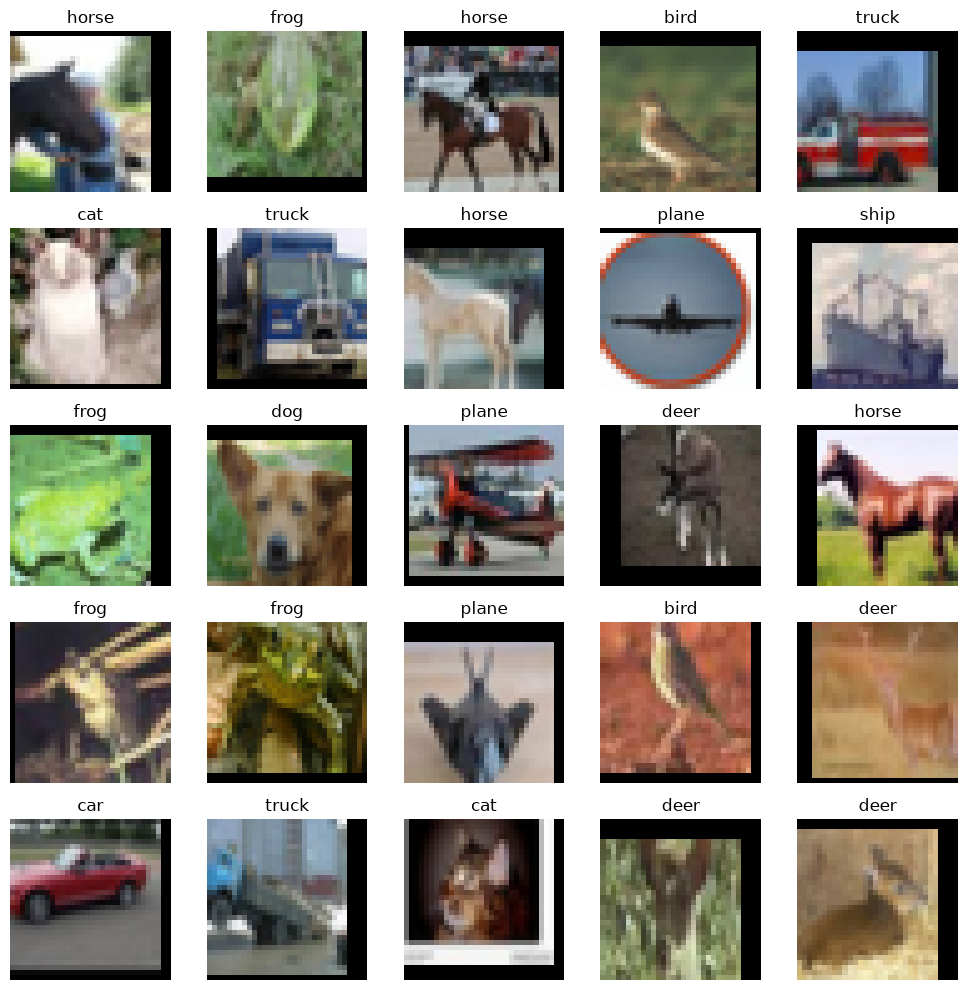

In [11]:
figure = plt.figure(figsize=(10, 10))
rows, cols = 5, 5

for index in range(rows * cols):
    image = denormalize(images[index], mean, std)

    axis = figure.add_subplot(rows, cols, index + 1)
    axis.imshow(to_pil_image(image))
    axis.set_title(class_names[labels[index].item()])
    axis.axis("off")

plt.tight_layout()
plt.show()

In [12]:
class AlexNetCIFAR10(nn.Module):
    def __init__(self, num_classes: int=10):  # __init__에 클래스를 넣어줘야 하는데 없으면 기본값 10
        super().__init__()

        self.features = nn.Sequential(
            # 입력 (128, 3, 32, 32)
            nn.Conv2d(3, 96, kernel_size=3, stride=1, padding=1),  # 3개의 채널을 집어넣으면 96개로 feature를 늘리겠다. 커널 사이즈: 3x3
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),
            # 출력 (128, 96, 16, 16)

            nn.Conv2d(96, 256, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),
            # 출력 (128, 256, 8, 8)

            nn.Conv2d(256, 384, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),

            # 같은 채널 수로 새로운 조합으로 384개 feature +1 layer 생성
            nn.Conv2d(384, 384, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),

            nn.Conv2d(384, 256, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2)
            # 출력: (배치, 256, 4, 4)

        )

        self.avgpool = nn.AdaptiveAvgPool2d((4, 4))
        
        self.classifier = nn.Sequential(
            nn.Dropout(p=0.5),  # 50% 무작위로 비활성
            nn.Linear(256*4*4, 1024),  # 4096개의 feature를 1024개로 줄이기
            nn.ReLU(inplace=True),

            nn.Dropout(p=0.5),  # 50% 무작위로 비활성
            nn.Linear(1024, 512),  # 1024 >> 512
            nn.ReLU(inplace=True),

            nn.Linear(512, num_classes)
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = self.features(x)
        x = self.avgpool(x)

        x = torch.flatten(x, start_dim = 1)
        logits = self.classifier(x)
        return logits


### 왜 마지막에 Softmax를 넣지 않을까?
- nn.CrossEntropyLoss()는 내부적으로 LogSoftmax와 NLLLoss를 결합해 계산함
- 모델의 마지막 층은 softmax 확률이 아니라 정규화되지 않은 점수이니 로짓을 출력해야 함

```
logits = model(image)
loss = criterion(logits, labels)
# 예측 확률을 확인할 때만 아래와 같이 Softmax 사용
probabilities = torch.softmax(logits, dim=1)
```

In [13]:
model = AlexNetCIFAR10(num_classes=10).to(DEVICE)
print(model)

AlexNetCIFAR10(
  (features): Sequential(
    (0): Conv2d(3, 96, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(96, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU(inplace=True)
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(256, 384, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU(inplace=True)
    (8): Conv2d(384, 384, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): ReLU(inplace=True)
    (10): Conv2d(384, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): ReLU(inplace=True)
    (12): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (avgpool): AdaptiveAvgPool2d(output_size=(4, 4))
  (classifier): Sequential(
    (0): Dropout(p=0.5, inplace=False)
    (1): Linear(in_features=4096, out_features=1024, bias=Tr

In [14]:
# parameter.numel(): 텐서안에 들어있는 원소의 개수를 구하는 함수
total_parameters = sum(parameter.numel() for parameter in model.parameters())
print(f'전체 파라미터 수: {total_parameters}')

전체 파라미터 수: 8046986


In [15]:
trainable_parameters = sum(
    parameter.numel() for parameter in model.parameters() if parameter.requires_grad  # grad: gradient (기울기)
)
print(f'학습 가능한 파라미터 수: {trainable_parameters}')

학습 가능한 파라미터 수: 8046986


In [16]:
# 더미 입력으로 각 단계의 크기 확인
dummy_input = torch.randn(2, 3, 32, 32).to(DEVICE)

with torch.inference_mode():  # 추론용 (학습때 사용한 gradient를 사용하지 않음)
    feature_output = model.features(dummy_input)
    pooled_output = model.avgpool(feature_output)
    logits = model(dummy_input)

print('입력: ', dummy_input.shape)
print('합성곱 특징: ', feature_output.shape)
print('AdaptiveAvgPool 이후: ', pooled_output.shape)
print('최종 logit: ', logits.shape)  # Batch size 2개가 10개의 확률로 나옴.

입력:  torch.Size([2, 3, 32, 32])
합성곱 특징:  torch.Size([2, 256, 4, 4])
AdaptiveAvgPool 이후:  torch.Size([2, 256, 4, 4])
최종 logit:  torch.Size([2, 10])


### 손실 함수와 최적화 방법
#### 손실 함수
- Linear Regression: MSE, RMSE
- Binary Classification: BCE Loss (Binary Classification Entropy)
- CrossEntropyLoss: 다중 클래스 분류에서 사용 (Multi Class Classification)
#### Optimizer
- AdamW: Adam의 편리한 최적화와 weight decay를 분리해 적용
- ReduceLROnPlateau: 검증 손실이 개선되지 않을 때 학습률 감소
- AdamW가 항상 SGD보다 우수한 것은 아니다. 원본 AlexNet은 momentum을 작용한 SGD를 사용했다.
- 이 ipynb 파일에서는 빠르게 실습 결과를 확인하기 위해 AdamW를 사용한다.


In [17]:
EPOCHS = 50
LEARNING_RATE = 1e-3
WEIGHT_DECAY = 1e-4

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    # mode='min': loss값이 작아질수록 좋다.
    # factor=0.5: 향상되지 않으면 learning rate를 절반으로 줄이기
    # patience=2: 두번 이상 향상 되지 않을 시 실행
    optimizer, mode='min', factor=0.5, patience=2
)

### 학습 함수

In [18]:
def train_one_epoch(data_loader, model, criterion, optimizer, device):
    model.train()
    total_loss = 0.0
    total_correct = 0
    total_samples = 0

    for images, labels in data_loader:
        # GPU에 보내서 저장
        images = images.to(device)  
        labels = labels.to(device)

        optimizer.zero_grad()  # 이전 기울기 초기화
        logits = model(images)  # 모델 추론 결과
        loss = criterion(logits, labels)  # 오차값 구하기
        loss.backward()  # model의 각 파라미터에 .grad 저장 
        optimizer.step()  # 각 파라미터의 .grad를 읽어 가중치 변경/업데이트
        batch_size = labels.size(0)
        total_loss += loss.item() * batch_size  # total_loss 누적
        total_correct += (logits.argmax(dim=1) == labels).sum().item()  # logit값중의 가장 확률이 큰 값이 label과 일치하면 True(1)
        total_samples += batch_size

    average_loss = total_loss / total_samples  # 평균 오차값
    accuracy = total_correct / total_samples  # 모델 정확도
    return average_loss, accuracy


### 평가 함수

In [19]:
def evaluate(data_loader, model, criterion, device):
    model.eval()  # 추론만 하기
    total_loss = 0.0
    total_correct = 0
    total_samples = 0

    # 학습 안되고 추론만 하기
    with torch.inference_mode():
        for images, labels in data_loader:
            # GPU로 보내기
            images = images.to(device)
            labels = labels.to(device)
            
            logits = model(images)
            loss = criterion(logits, labels)
            batch_size = labels.size(0)
            total_loss += loss.item() * batch_size
            total_correct += (logits.argmax(dim=1) == labels).sum().item()
            total_samples += batch_size

    average_loss = total_loss / total_samples
    accuracy = total_correct / total_samples
    return average_loss, accuracy

### 학습 및 최고 모델 저장
- 검증 손실이 가장 낮을 때의 가중치만 저장함
- 마지막 epoch의 모델이 항상 가장 좋은 모델을 아님 (loss값이 오히려 올라갈 수 도 있음)
- 조기 종료는 검증 손실이 여러 에포크 동안 개선되지 않으면 학습을 끝내 과적합과 불필요한 연산을 줄임

In [20]:
OUTPUT_DIR = Path("outputs")
OUTPUT_DIR.mkdir(exist_ok=True)
BEST_MODEL_PATH = OUTPUT_DIR / "alexnet_cifar10_best.pth"
EARLY_STOPPING_PATIENCE = 5

In [21]:
history = {
    "train_loss": [],
    "train_accuracy": [],
    "validation_loss": [],
    "validation_accuracy": [],
}

best_validation_loss = float('inf')  # 양의 무한대값 저장 (비교하며 줄어들것이기 때문에 제일 큰 값으로 초기화)
epoch_without_improvement = 0

for epoch in range(1, EPOCHS + 1):
    train_loss, train_accuracy = train_one_epoch(
        train_loader, model, criterion, optimizer, DEVICE
    )
    validation_loss, validation_accuracy = evaluate(
        validation_loader, model, criterion, DEVICE
    )
    scheduler.step(validation_loss)

    history['train_loss'].append(train_loss)
    history['train_accuracy'].append(train_accuracy)
    history['validation_loss'].append(validation_loss)
    history['validation_accuracy'].append(validation_accuracy)

    current_lr = optimizer.param_groups[0]["lr"]
    print(f'Epoch [{epoch:02d}/{EPOCHS}]'
        f'lr={current_lr:.6f} | '
        f'train loss={train_loss:.4f}, acc={train_accuracy:.4f} | '
        f'val loss={validation_loss:.4f}, acc={validation_accuracy:.4f}'
    )

    if validation_loss < best_validation_loss:
        best_validation_loss = validation_loss
        epoch_without_improvement = 0
        torch.save(model.state_dict(), BEST_MODEL_PATH)
        print(f'최고 모델 저장: {BEST_MODEL_PATH}')
    else:
        epoch_without_improvement += 1
        if epoch_without_improvement >= EARLY_STOPPING_PATIENCE:
            print('조기 종료: 검증 손실이 더 이상 개선되지 않았습니다.')
            break


Epoch [01/50]lr=0.001000 | train loss=1.8230, acc=0.3062 | val loss=1.4674, acc=0.4568
최고 모델 저장: outputs\alexnet_cifar10_best.pth
Epoch [02/50]lr=0.001000 | train loss=1.4382, acc=0.4702 | val loss=1.3321, acc=0.5032
최고 모델 저장: outputs\alexnet_cifar10_best.pth
Epoch [03/50]lr=0.001000 | train loss=1.2670, acc=0.5415 | val loss=1.1058, acc=0.6014
최고 모델 저장: outputs\alexnet_cifar10_best.pth
Epoch [04/50]lr=0.001000 | train loss=1.1394, acc=0.5919 | val loss=0.9724, acc=0.6506
최고 모델 저장: outputs\alexnet_cifar10_best.pth
Epoch [05/50]lr=0.001000 | train loss=1.0442, acc=0.6282 | val loss=0.9181, acc=0.6668
최고 모델 저장: outputs\alexnet_cifar10_best.pth
Epoch [06/50]lr=0.001000 | train loss=0.9646, acc=0.6590 | val loss=0.8274, acc=0.7012
최고 모델 저장: outputs\alexnet_cifar10_best.pth
Epoch [07/50]lr=0.001000 | train loss=0.9020, acc=0.6833 | val loss=0.8192, acc=0.7110
최고 모델 저장: outputs\alexnet_cifar10_best.pth
Epoch [08/50]lr=0.001000 | train loss=0.8554, acc=0.7014 | val loss=0.7977, acc=0.7184
최고 

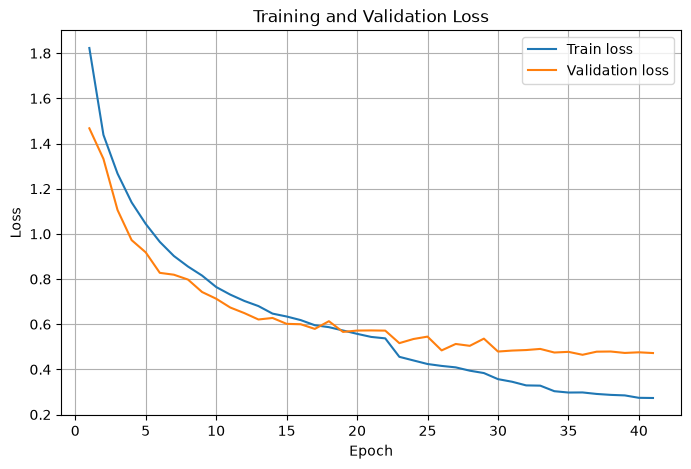

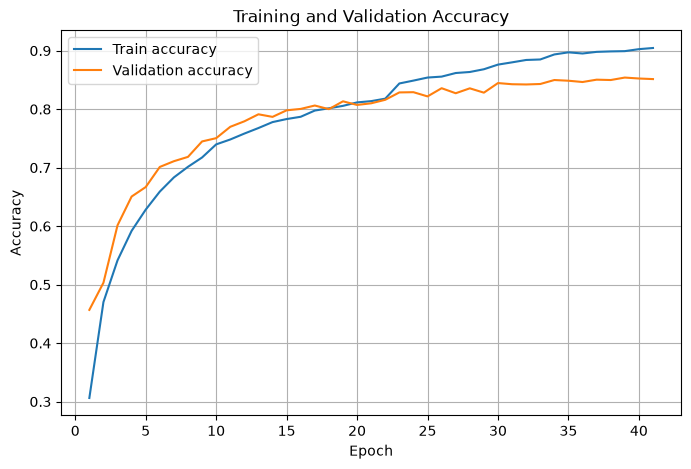

In [23]:
epochs = range(1, len(history["train_loss"]) + 1)

plt.figure(figsize=(8, 5))
plt.plot(epochs, history["train_loss"], label="Train loss")
plt.plot(epochs, history["validation_loss"], label="Validation loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")
plt.legend()
plt.grid()
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(epochs, history["train_accuracy"], label="Train accuracy")
plt.plot(epochs, history["validation_accuracy"], label="Validation accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training and Validation Accuracy")
plt.legend()
plt.grid()
plt.show()

# **2. Alexnet 모델 최종 평가**
- 학습과 모델 선택이 모두 끝난 뒤 저장해 둔 최고 모델을 불러옴
- 테스트 데이터는 최종 성능 확인에만 사용

In [25]:
try:
    best_state_dict = torch.load(
        BEST_MODEL_PATH,
        map_location=DEVICE,
        weights_only=True,  # 가중치만 불러오기
    )
except TypeError:
    best_state_dict = torch.load(BEST_MODEL_PATH, map_location=DEVICE)

model.load_state_dict(best_state_dict)

test_loss, test_accuracy = evaluate(
    test_loader, model, criterion, DEVICE
)

print(f"테스트 손실: {test_loss:.4f}")
print(f"테스트 정확도: {test_accuracy * 100:.2f}%")

테스트 손실: 0.4981
테스트 정확도: 84.54%


### 혼동행렬과 클래스별 성능

In [26]:
from sklearn.metrics import confusion_matrix, classification_report

In [27]:
def collect_predictions(data_loader, model, device):
    model.eval()

    true_labels = []
    predicted_labels = []

    with torch.inference_mode():
        for images, labels in data_loader:
            images = images.to(device)

            logits = model(images)
            predictions = logits.argmax(dim=1).cpu()  # logit값들 중 가장 높은 값을 cpu로 보내서 저장 (Numpy 계산 할 때는 cpu에서만 가능)

            true_labels.extend(labels.numpy().tolist())
            predicted_labels.extend(predictions.numpy().tolist())

    return np.array(true_labels), np.array(predicted_labels)


true_labels, predicted_labels = collect_predictions(
    test_loader, model, DEVICE
)

confusion = confusion_matrix(true_labels, predicted_labels)
confusion

array([[874,   8,  35,  10,   6,   0,   3,   8,  34,  22],
       [  6, 932,   2,   3,   0,   1,   4,   0,  16,  36],
       [ 33,   1, 800,  24,  44,  33,  38,  16,   8,   3],
       [ 17,   3,  42, 644,  42, 166,  46,  20,   9,  11],
       [ 11,   1,  44,  29, 826,  22,  31,  29,   3,   4],
       [  8,   2,  25, 105,  36, 786,  10,  24,   3,   1],
       [  6,   4,  34,  27,  10,  16, 892,   5,   4,   2],
       [ 15,   2,  27,  18,  21,  35,   1, 876,   2,   3],
       [ 42,   5,  11,   4,   1,   2,   1,   2, 922,  10],
       [ 15,  42,   6,   3,   1,   2,   6,   3,  20, 902]])

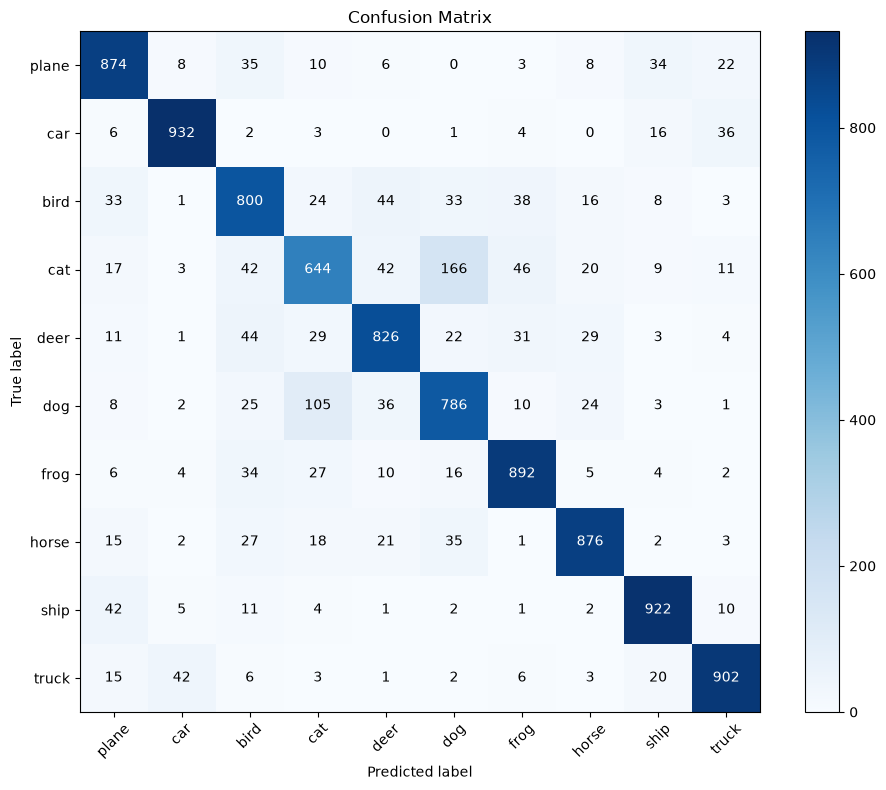

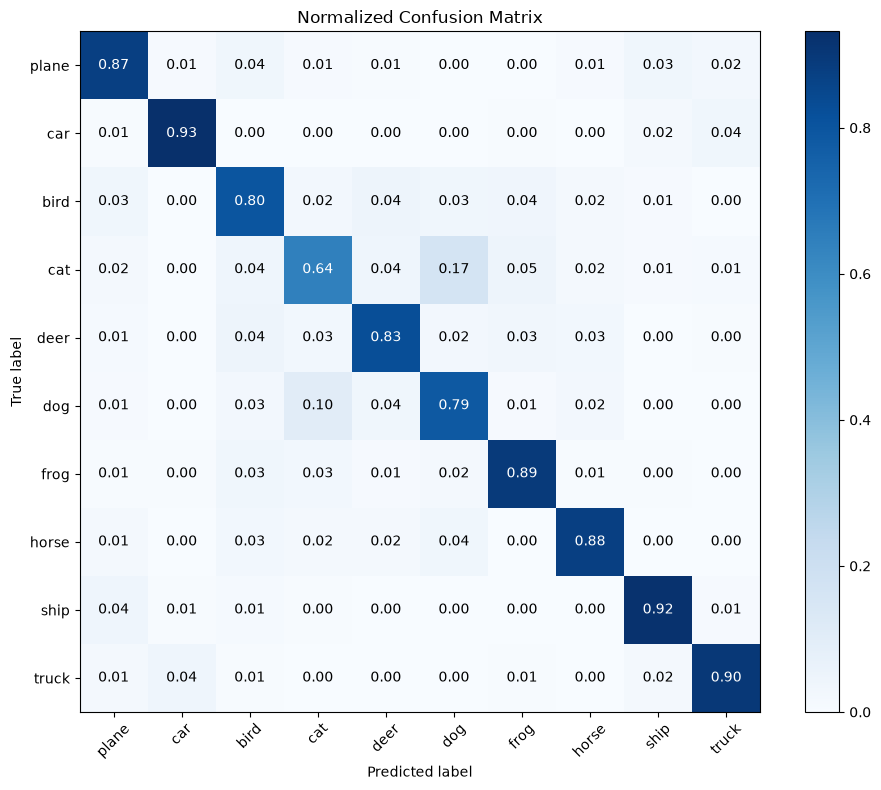

In [28]:
def plot_confusion_matrix(
    matrix: np.ndarray,
    class_names,
    normalize: bool = False,
):
    display_matrix = matrix.astype(float)

    if normalize:
        row_sums = display_matrix.sum(axis=1, keepdims=True)
        display_matrix = np.divide(
            display_matrix,
            row_sums,
            out=np.zeros_like(display_matrix),
            where=row_sums != 0,
        )

    plt.figure(figsize=(10, 8))
    plt.imshow(display_matrix, interpolation="nearest", cmap="Blues")
    plt.title("Normalized Confusion Matrix" if normalize else "Confusion Matrix")
    plt.colorbar()

    tick_positions = np.arange(len(class_names))
    plt.xticks(tick_positions, class_names, rotation=45)
    plt.yticks(tick_positions, class_names)

    threshold = display_matrix.max() / 2

    for row in range(display_matrix.shape[0]):
        for column in range(display_matrix.shape[1]):
            value = display_matrix[row, column]
            text = f"{value:.2f}" if normalize else f"{int(value)}"

            plt.text(
                column,
                row,
                text,
                ha="center",
                va="center",
                color="white" if value > threshold else "black",
            )

    plt.ylabel("True label")
    plt.xlabel("Predicted label")
    plt.tight_layout()
    plt.show()


plot_confusion_matrix(confusion, class_names, normalize=False)
plot_confusion_matrix(confusion, class_names, normalize=True)

In [29]:
print(
    classification_report(
        true_labels,
        predicted_labels,
        target_names=class_names,
        digits=4,
        zero_division=0,
    )
)

              precision    recall  f1-score   support

       plane     0.8510    0.8740    0.8624      1000
         car     0.9320    0.9320    0.9320      1000
        bird     0.7797    0.8000    0.7897      1000
         cat     0.7428    0.6440    0.6899      1000
        deer     0.8369    0.8260    0.8314      1000
         dog     0.7394    0.7860    0.7620      1000
        frog     0.8643    0.8920    0.8780      1000
       horse     0.8911    0.8760    0.8835      1000
        ship     0.9030    0.9220    0.9124      1000
       truck     0.9074    0.9020    0.9047      1000

    accuracy                         0.8454     10000
   macro avg     0.8448    0.8454    0.8446     10000
weighted avg     0.8448    0.8454    0.8446     10000

